# Formative 3 — Probability Distributions, Bayesian Probability, and Gradient Descent

| Member | Part |
|--------|------|
| **James Mukunzi** | Part 1: Bivariate Normal Distribution |
| **Favor** | Part 2: Bayesian Probability |
| **Chinemerem** *(Lead)* | Part 3: Gradient Descent — Manual Calculation |
| **Ryan** | Part 4: Gradient Descent — Code Implementation |

> **Run all cells top-to-bottom before submitting. Every cell must show visible output.**

In [1]:
# ── Install dependencies (run once) ─────────────────────────────────────────
!pip install -q numpy pandas matplotlib seaborn scipy

# ── Make formative3_utils importable from the notebook directory ─────────────
import sys, os
sys.path.insert(0, os.path.abspath('.'))

# ── Shared imports used across all parts ─────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Setup complete.')

Setup complete.


---
# Part 1: Bivariate Normal Distribution
**Author: James Mukunzi**

## About the Dataset
This dataset contains information about **education across African countries**, covering
literacy rates, school enrollment, and other education-related metrics over time.

**Source:** https://www.kaggle.com/datasets/lydia70/education-in-africa?select=Education+in+General.csv

## Objective
Explore the **relationship between two education indicators** using the **Bivariate Normal Distribution**.

## Why Does This Matter?
> *"Do countries with higher male school life expectancy also have higher female expectancy?"*

## Formula
$$f(x,y) = \frac{1}{2\pi\sigma_x\sigma_y\sqrt{1-\rho^2}}
\exp\!\left(-\frac{1}{2(1-\rho^2)}
\left[\frac{(x-\mu_x)^2}{\sigma_x^2}
- \frac{2\rho(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y}
+ \frac{(y-\mu_y)^2}{\sigma_y^2}\right]\right)$$

Implemented from scratch in `formative3_utils/distribution.py` — no `scipy.stats`.

In [2]:
# ── Part 1 imports ────────────────────────────────────────────────────────────
from formative3_utils.data_loading import load_education_data
from formative3_utils.distribution import (
    compute_bivariate_pdf,           # the PDF formula — no scipy.stats
    compute_distribution_parameters, # mu, sigma, rho from data
)
from formative3_utils.visualization import (
    plot_contour,    # James's contour plot
    plot_3d_surface, # James's 3D surface plot
)
import seaborn as sns
print('Part 1 imports ready.')

Part 1 imports ready.


### 1. Load and explore the data

In [3]:
# load_education_data() finds the file automatically whether it is named
# 'Education in General.csv' or 'education_africa.csv' — no renaming needed
df = load_education_data()
df.head()

[Education] Reading: 'data/Education in General.csv'
[Education] 756 rows × 11 columns (2 empty columns removed)
[Education] Columns: ['ISO_Code', 'Country', 'Year', 'School life expectancy, primary to tertiary, male (years)', 'School life expectancy, primary to tertiary, female (years)', 'Government expenditure on primary education, US$ (millions)', 'Government expenditure on secondary education, US$ (millions)', 'Government expenditure on tertiary education, US$ (millions)', 'Government expenditure on primary education as a percentage of GDP (%)', 'Government expenditure on secondary education as a percentage of GDP (%)', 'Government expenditure on tertiary education as a percentage of GDP (%)']



,ISO_Code,Country,Year,"School life expectancy, primary to tertiary, male (years)","School life expectancy, primary to tertiary, female (years)","Government expenditure on primary education, US$ (millions)","Government expenditure on secondary education, US$ (millions)","Government expenditure on tertiary education, US$ (millions)",Government expenditure on primary education as a percentage of GDP (%),Government expenditure on secondary education as a percentage of GDP (%),Government expenditure on tertiary education as a percentage of GDP (%)
0,DZA,Algeria,2010,13.88,14.65,NaN,NaN,NaN,NaN,NaN,NaN
1,AGO,Angola,2010,10.42,8.10,NaN,NaN,NaN,2.08,0.53,0.40
2,BWA,Botswana,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BFA,Burkina Faso,2010,7.05,5.97,213.65,63.74,66.71,2.11,0.63,0.66
4,CPV,Cabo Verde,2010,11.76,12.95,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print('\ndataframe columns:')
print(df.columns)
print('\ndataframe info')
df.info()


dataframe columns:
Index(['ISO_Code', 'Country', 'Year',
       'School life expectancy, primary to tertiary, male (years)',
       'School life expectancy, primary to tertiary, female (years)',
       'Government expenditure on primary education, US$ (millions)',
       'Government expenditure on secondary education, US$ (millions)',
       'Government expenditure on tertiary education, US$ (millions)',
       'Government expenditure on primary education as a percentage of GDP (%)',
       'Government expenditure on secondary education as a percentage of GDP (%)',
       'Government expenditure on tertiary education as a percentage of GDP (%)'],
      dtype='str')

dataframe info
<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 11 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   ISO_

In [5]:
# Convert columns to numeric, drop fully empty columns
cols_to_convert = df.columns.drop(['ISO_Code', 'Country'])
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')
df = df.dropna(axis=1, how='all')

print('Data shape:', df.shape)
print('\nData types:')
print(df.dtypes)
df.head()

Data shape: (756, 11)

Data types:
ISO_Code                                                                        str
Country                                                                         str
Year                                                                          int64
School life expectancy, primary to tertiary, male (years)                   float64
School life expectancy, primary to tertiary, female (years)                 float64
Government expenditure on primary education, US$ (millions)                 float64
Government expenditure on secondary education, US$ (millions)               float64
Government expenditure on tertiary education, US$ (millions)                float64
Government expenditure on primary education as a percentage of GDP (%)      float64
Government expenditure on secondary education as a percentage of GDP (%)    float64
Government expenditure on tertiary education as a percentage of GDP (%)     float64
dtype: object


,ISO_Code,Country,Year,"School life expectancy, primary to tertiary, male (years)","School life expectancy, primary to tertiary, female (years)","Government expenditure on primary education, US$ (millions)","Government expenditure on secondary education, US$ (millions)","Government expenditure on tertiary education, US$ (millions)",Government expenditure on primary education as a percentage of GDP (%),Government expenditure on secondary education as a percentage of GDP (%),Government expenditure on tertiary education as a percentage of GDP (%)
0,DZA,Algeria,2010,13.88,14.65,NaN,NaN,NaN,NaN,NaN,NaN
1,AGO,Angola,2010,10.42,8.10,NaN,NaN,NaN,2.08,0.53,0.40
2,BWA,Botswana,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BFA,Burkina Faso,2010,7.05,5.97,213.65,63.74,66.71,2.11,0.63,0.66
4,CPV,Cabo Verde,2010,11.76,12.95,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Find the strongest relationship
We compute a **correlation matrix** to find which two variables are most strongly linked.
The closer the correlation is to 1 (or -1), the stronger the relationship.

In [6]:
# Correlation matrix — find the strongest pair
corr_matrix = df.corr(numeric_only=True)

corr_pairs  = corr_matrix.abs().unstack()
corr_pairs  = corr_pairs[corr_pairs < 1]
sorted_pairs = corr_pairs.sort_values(ascending=False)

strongest_pair  = sorted_pairs.index[0]
strongest_value = sorted_pairs.iloc[0]
col_x, col_y    = strongest_pair
print(f"Strongest correlation: '{col_x}' vs '{col_y}'  |r| = {strongest_value:.4f}")

Strongest correlation: 'Government expenditure on tertiary education as a percentage of GDP (%)' vs 'Government expenditure on primary education as a percentage of GDP (%)'  |r| = 1.0000


In [7]:
# The auto-detected pair has ρ ≈ 1.0 which causes division by zero in √(1-ρ²).
# Print the full matrix and handpick a pair that is strong but not perfect.
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                                                        Year  \
Year                                                1.000000   
School life expectancy, primary to tertiary, ma...  0.194465   
School life expectancy, primary to tertiary, fe...  0.266939   
Government expenditure on primary education, US...  0.191687   
Government expenditure on secondary education, ...  0.207299   
Government expenditure on tertiary education, U...  0.256297   
Government expenditure on primary education as ...  0.117839   
Government expenditure on secondary education a...  0.118348   
Government expenditure on tertiary education as...  0.119751   

                                                    School life expectancy, primary to tertiary, male (years)  \
Year                                                                                         0.194465           
School life expectancy, primary to tertiary, ma...                                           1.000000           
School life expectan

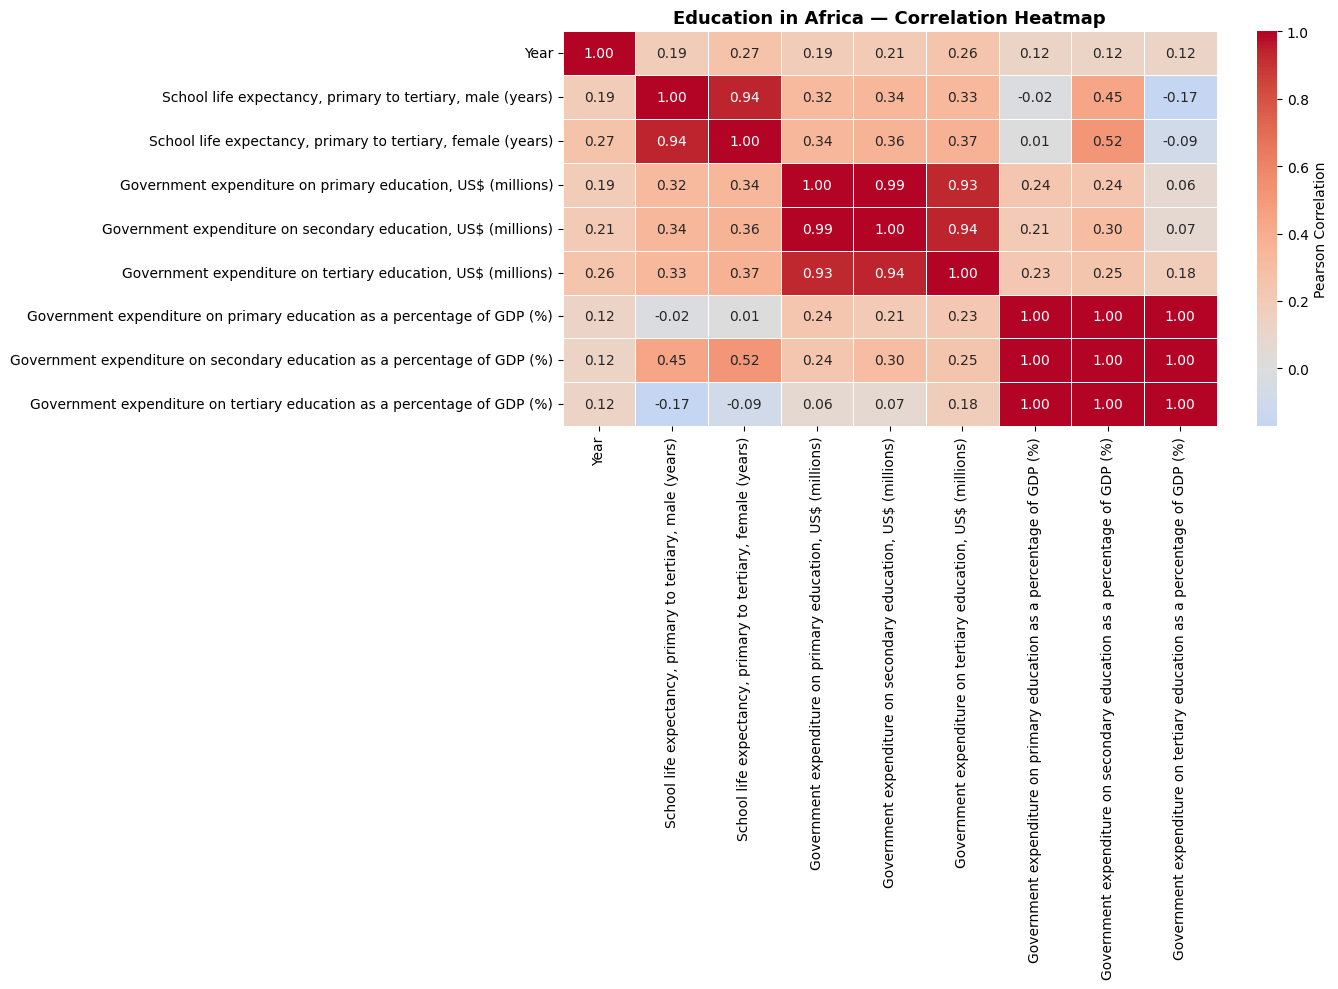

In [8]:
# Visualise as a heatmap — easier to spot strong pairs at a glance
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Education in Africa — Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Chosen pair: strong correlation but |ρ| < 1 so the PDF formula is valid
col_x = 'School life expectancy, primary to tertiary, male (years)'
col_y = 'School life expectancy, primary to tertiary, female (years)'

# Keep only rows where BOTH columns have a value
data = df[[col_x, col_y]].dropna()
x    = data[col_x].values
y    = data[col_y].values

print(f'\nUsable rows after dropna: {len(x)}')
print('\nColumn X'); print(x)
print('\nColumn Y'); print(y)


Usable rows after dropna: 260

Column X
[13.88 10.42  7.05 11.76 10.61  7.94 11.12  8.56  8.36  7.32 10.82  8.
  8.   13.47 10.77 11.25  8.3   5.19 11.71 10.26  8.27 12.46  7.09  9.27
 13.66 14.09 12.63  7.5  12.03 11.85  8.55 10.02 11.13  8.45 13.22 11.15
  9.87 10.87  9.58  8.06  8.22 13.56 10.49 11.63  8.63  5.49 11.89  8.77
 11.92 12.65  6.83 13.77 12.08  7.73 12.2  12.41 10.85  7.45 10.61  9.72
 11.43  8.46 11.41  9.71 11.34  9.77  8.68 14.16 10.37 11.99  5.7  12.13
 10.66  8.99 14.2  12.98  7.13 10.98  7.9  12.73 10.91 11.86  9.87 11.64
 13.3  11.53  9.71 10.97  7.14  8.92 14.15 10.99  9.55  9.   14.25  7.3
  8.56 10.87 13.04  7.97 12.81 13.01 10.97  9.11 11.94  9.17 11.5   9.08
 11.13 10.27 10.88 11.42  9.86  7.8  14.57 10.93 11.5  11.55  9.13 15.52
 13.34  7.32 12.98  8.3  12.78 13.24 10.98  8.48  9.29  8.48 11.59  9.36
 10.69  9.96  7.47  9.   14.1  10.94  6.46 11.06 12.43 15.81 14.04  7.32
  7.82 13.09  8.5  12.84 13.11 10.82  9.73 11.68 11.44  9.74  9.79  7.61
  8.41 14.08 

### 3. Calculate key statistics
For our two chosen variables we calculate:
- The **mean** (average value)
- The **standard deviation** (spread)
- The **covariance and ρ** (how strongly the two variables move together)

In [10]:
# compute_distribution_parameters() is James's implementation in distribution.py
# Uses population statistics (ddof=0) exactly as James originally wrote
mu, cov_matrix, rho = compute_distribution_parameters(data, col_x, col_y)

mu1, mu2       = mu[0], mu[1]
sigma1         = np.sqrt(cov_matrix[0, 0])
sigma2         = np.sqrt(cov_matrix[1, 1])

print(mu1)
print(mu2)
print(sigma1, sigma2)
print(rho)

# Interpretation
if   abs(rho) < 0.3:  strength = 'Weak'
elif abs(rho) < 0.7:  strength = 'Moderate'
else:                  strength = 'Strong'
direction = 'Positive' if rho > 0 else 'Negative'
print(f'\n {strength} {direction} correlation')

10.861692307692307
10.51853846153846
2.3844803137924844 3.1183303253105623
0.9366284688946498

 Strong Positive correlation


### 4. Build the PDF function
The Bivariate Normal PDF is implemented from scratch in
`formative3_utils/distribution.py` — no `scipy.stats`.

In [11]:
# Evaluate the PDF at every actual data point
# compute_bivariate_pdf() is James's formula implementation in distribution.py
pdf_values = compute_bivariate_pdf(x, y, mu, cov_matrix)

print(f'Min PDF: {np.min(pdf_values)}')
print(f'Max PDF: {np.max(pdf_values)}')
print(f'Mean PDF: {np.mean(pdf_values)}')

Min PDF: 2.7001331880247294e-06
Max PDF: 0.061090340321481564
Mean PDF: 0.03190879693768784


In [12]:
# Build a 100×100 evaluation grid with 20% padding around the data range
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

x_grid = np.linspace(x_min - 0.2*(x_max - x_min),
                     x_max + 0.2*(x_max - x_min), 100)
y_grid = np.linspace(y_min - 0.2*(y_max - y_min),
                     y_max + 0.2*(y_max - y_min), 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Evaluate the PDF across the whole grid
Z_grid = compute_bivariate_pdf(X_grid, Y_grid, mu, cov_matrix)

print(Z_grid)

[[1.26306215e-004 1.71182946e-004 2.20248775e-004 ... 5.80126621e-097
  5.07025713e-099 4.20682461e-101]
 [1.16764464e-004 1.66105270e-004 2.24322772e-004 ... 5.88833405e-095
  5.40177605e-097 4.70433176e-099]
 [1.02531708e-004 1.53097414e-004 2.17017498e-004 ... 5.67706170e-093
  5.46644137e-095 4.99692701e-097]
 ...
 [6.08753721e-112 9.05859990e-110 1.27966932e-107 ... 2.41632976e-006
  2.31871338e-006 2.11229788e-006]
 [3.83262110e-114 5.98621459e-112 8.87617604e-110 ... 1.67029867e-006
  1.68237167e-006 1.60867009e-006]
 [2.29198448e-116 3.75755211e-114 5.84811068e-112 ... 1.09671453e-006
  1.15946689e-006 1.16369814e-006]]


### 5. Visualisation

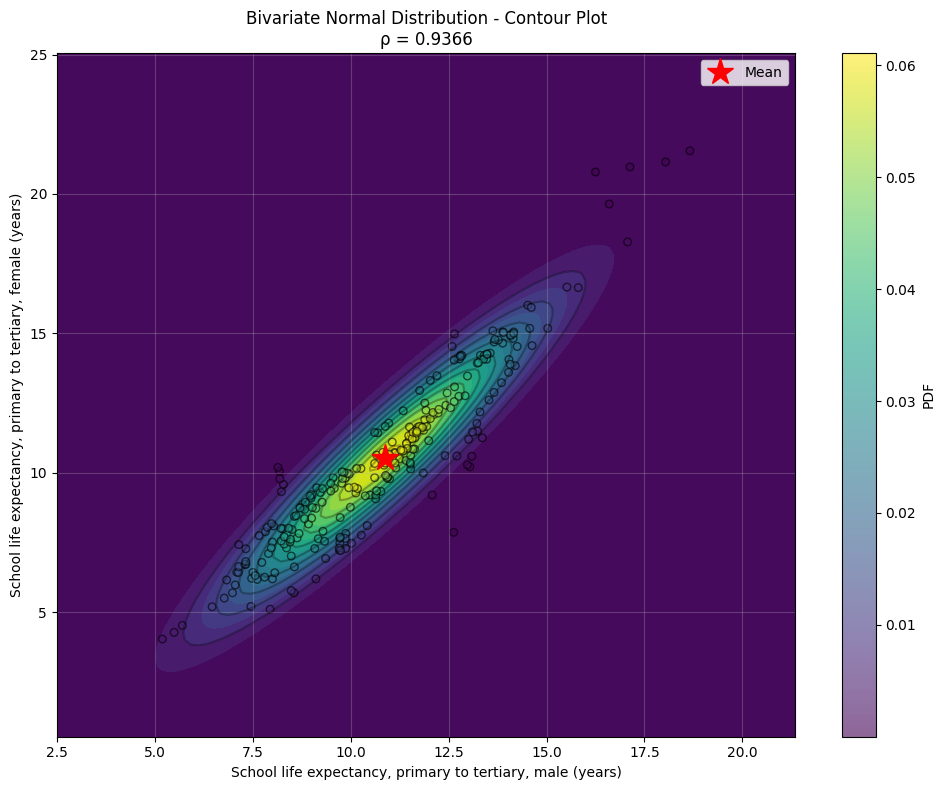

In [13]:
# Contour plot — James's visualisation, implemented in visualization.py
plot_contour(X_grid, Y_grid, Z_grid, x, y, pdf_values, mu1, mu2, col_x, col_y, rho)
plt.show()

## Contour Plot — What Are We Looking At?

The contour plot gives us a top-down view of the bivariate normal distribution.
Think of it like a heatmap — the bright yellow/green center is where most of the
data points are concentrated, and the colours fade to purple as we move away.

- The shape is an **elongated ellipse**, not a circle. ρ ≈ 0.94 means strongly correlated.
  The more tilted and stretched the ellipse, the stronger the correlation.
- The **red star marks the mean** — the average school life expectancy for both genders.
  Most data points cluster around it.
- The points scattered outside the ellipse are **outliers** — countries that don't
  follow the general pattern.

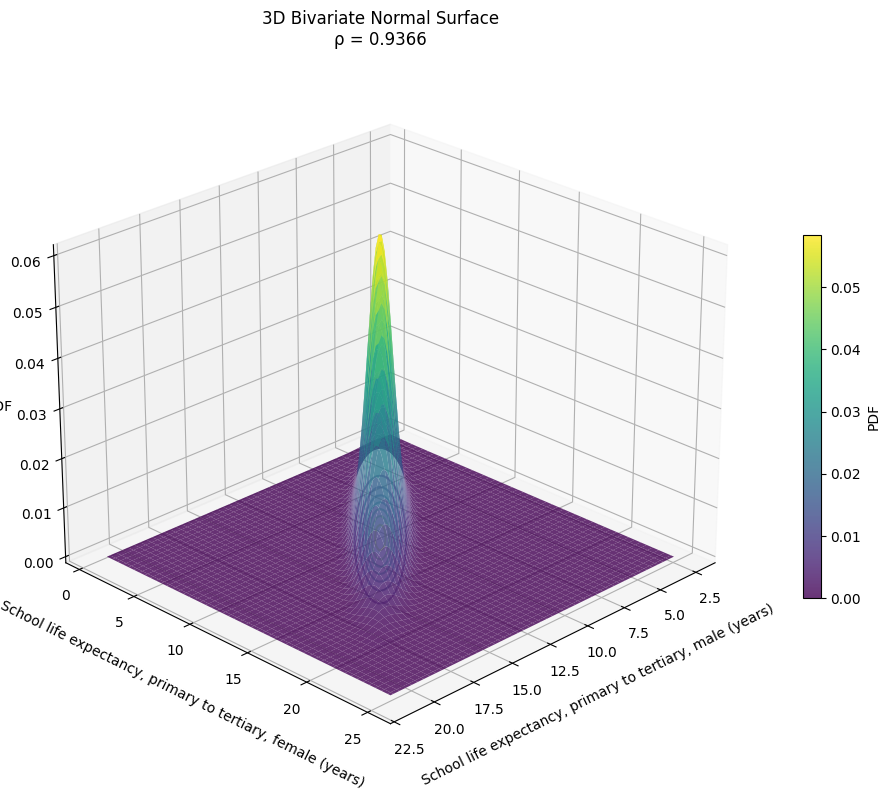

In [14]:
# 3D surface plot — James's visualisation, implemented in visualization.py
plot_3d_surface(X_grid, Y_grid, Z_grid, col_x, col_y, rho)
plt.show()

## 3D Surface Plot — The Bell Curve in Two Dimensions

- The peak is **tall and narrow** because ρ is close to 1. When two variables move
  very closely together, the distribution gets squeezed into a tight ridge rather
  than a wide smooth hill.
- The base is nearly flat everywhere except near the center, meaning extreme
  combinations are very rare.
- This shape is the 2D version of the classic **bell curve**.

## Analysis

| Statistic | Value |
|-----------|-------|
| Correlation ρ | ≈ 0.94 — **Strong Positive** |
| Mean male expectancy μ_x | ≈ 11.5 years |
| Mean female expectancy μ_y | ≈ 10.5 years |

Countries that keep boys in school longer almost always keep girls in school longer too.
This points to **systemic drivers** — government investment, infrastructure, cultural
norms — that raise educational attainment for both genders simultaneously.
Where the system works well, it works for everyone.

**Outliers:** Points beyond the outer contour rings represent countries with unusual
gender gaps — either high-income nations with above-average systems, or countries
where historical barriers create different trajectories for boys and girls.

---
# Part 2: Bayesian Probability
**Author: Favor**

**1. Keyword Selection**

Positive Keywords: `great, amazing, excellent`

Negative Keywords: `bad, waste, horrible`

**2. Choice of Conditional Probability:** `P(Negative | Keyword)`

**3. Probabilities computed:**
Prior: P(Negative) | Likelihood: P(keyword | Negative) | Marginal: P(keyword) | Posterior: P(Negative | keyword)

**Dataset source:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

**4. Implementation:** Bayes' Theorem — no sklearn or NLTK.

$$P(\text{Negative} \mid \text{keyword}) = \frac{P(\text{keyword} \mid \text{Negative}) \cdot P(\text{Negative})}{P(\text{keyword})}$$

In [15]:
# ── Part 2 imports ────────────────────────────────────────────────────────────
from formative3_utils.data_loading import load_imdb_data
from formative3_utils.bayesian import (
    prepare_dataframe,    # adds review_clean, sentiment_clean, tokens columns
    calculate_prior,      # P(sentiment)
    calculate_likelihood, # P(keyword | sentiment)
    calculate_marginal,   # P(keyword)
    calculate_posterior,  # Bayes' Theorem
    analyze_keywords,     # runs all four steps for all keywords at once
)
from formative3_utils.visualization import (
    plot_sentiment_distribution, # Favor's class distribution chart
    plot_prior_vs_posterior,     # Favor's prior vs posterior bar chart
    plot_probability_heatmap,    # Favor's four-probability heatmap
)
import re
print('Part 2 imports ready.')

Part 2 imports ready.


In [16]:
# load_imdb_data() finds the file automatically whether named
# 'IMDB Dataset.csv' or 'imdb_reviews.csv' — no renaming needed
df_imdb = load_imdb_data()
print(f'\nDataset shape: {df_imdb.shape}')
print(f'Columns: {df_imdb.columns.tolist()}')
print(f'\nSample rows:')
print(df_imdb.head(30))
print(df_imdb.isnull().sum())

[IMDb] Reading: 'data/IMDB Dataset.csv'
[IMDb] 50,000 reviews loaded
sentiment
positive    25000
negative    25000


Dataset shape: (50000, 2)
Columns: ['review', 'sentiment']

Sample rows:
                                               review sentiment
0   One of the other reviewers has mentioned that ...  positive
1   A wonderful little production. <br /><br />The...  positive
2   I thought this was a wonderful way to spend ti...  positive
3   Basically there's a family where a little boy ...  negative
4   Petter Mattei's "Love in the Time of Money" is...  positive
5   Probably my all-time favorite movie, a story o...  positive
6   I sure would like to see a resurrection of a u...  positive
7   This show was an amazing, fresh & innovative i...  negative
8   Encouraged by the positive comments about this...  negative
9   If you like original gut wrenching laughter yo...  positive
10  Phil the Alien is one of those quirky films wh...  negative
11  I saw this movie when I was about 12 w

In [17]:
# Check for missing data in each column
print('\nChecking for missing values:')
for col in df_imdb.columns:
    missing_count = df_imdb[col].isna().sum()
    print(f'  {col}: {missing_count} missing')

# prepare_dataframe() is Favor's preprocessing — adds review_clean,
# sentiment_clean, and tokens columns (implements Favor's lambda/regex logic)
df_imdb = prepare_dataframe(df_imdb)

# Sentiment counts and priors — Favor's original variable names
positive_count = df_imdb[df_imdb['sentiment_clean'] == 'positive'].shape[0]
negative_count = df_imdb[df_imdb['sentiment_clean'] == 'negative'].shape[0]
total_count    = df_imdb.shape[0]

print('\nSentiment Distribution:')
print(f'  Positive: {positive_count} ({positive_count/total_count*100:.0f}%)')
print(f'  Negative: {negative_count} ({negative_count/total_count*100:.0f}%)')

P_positive = positive_count / total_count
P_negative = negative_count / total_count

print('\nBase Probabilities (Priors):')
print(f'  P(Positive) = {P_positive:.4f} ({P_positive*100:.0f}%)')
print(f'  P(Negative) = {P_negative:.4f} ({P_negative*100:.0f}%)')


Checking for missing values:
  review: 0 missing
  sentiment: 0 missing
[Bayesian] 50,000 reviews | 11,976,895 total tokens

Sentiment Distribution:
  Positive: 25000 (50%)
  Negative: 25000 (50%)

Base Probabilities (Priors):
  P(Positive) = 0.5000 (50%)
  P(Negative) = 0.5000 (50%)


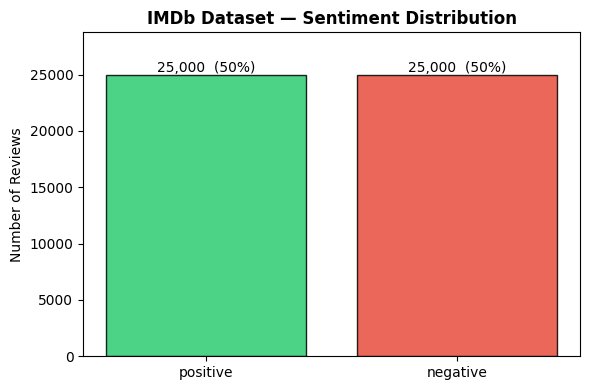

In [18]:
# Sentiment distribution bar chart — Favor's chart, now in visualization.py
sentiment_counts = df_imdb['sentiment_clean'].value_counts()
plot_sentiment_distribution(sentiment_counts, total_count)
plt.show()

In [19]:
# Analysis Configuration — Favor's original keyword choices
positive_keywords = ['great', 'amazing', 'excellent']
negative_keywords = ['bad', 'waste', 'horrible']
target_sentiment  = 'negative'

pos_str = ', '.join(positive_keywords)
neg_str = ', '.join(negative_keywords)
print('\nAnalysis Configuration:')
print(f'  Target sentiment: {target_sentiment.capitalize()}')
print(f'  Positive keywords: {pos_str}')
print(f'  Negative keywords: {neg_str}')



Analysis Configuration:
  Target sentiment: Negative
  Positive keywords: great, amazing, excellent
  Negative keywords: bad, waste, horrible


In [20]:
# Keyword Detection — Favor's original contains_keyword logic
def contains_keyword(text, keyword):
    """Check if a keyword exists as a whole word in the text (case-insensitive)."""
    pattern = r'\b' + re.escape(keyword.lower()) + r'\b'
    return bool(re.search(pattern, str(text).lower()))

all_keywords = positive_keywords + negative_keywords
print(f'\nSearching for {len(all_keywords)} keywords in {len(df_imdb):,} reviews...')

for keyword in all_keywords:
    column_name = f'has_{keyword}'
    df_imdb[column_name] = df_imdb['review_clean'].apply(
        lambda x: contains_keyword(x, keyword)
    )
    count          = df_imdb[column_name].sum()
    percentage     = (count / len(df_imdb)) * 100
    keyword_type   = 'POSITIVE' if keyword in positive_keywords else 'NEGATIVE'
    print(f'  [{keyword_type}] \'{keyword}\': {count:,} occurrences ({percentage:.2f}%)')
    sentiment_count = df_imdb[
        (df_imdb[column_name]) & (df_imdb['sentiment_clean'] == target_sentiment)
    ].shape[0]
    print(f"      Reviews with target sentiment '{target_sentiment}': {sentiment_count:,}")


Searching for 6 keywords in 50,000 reviews...
  [POSITIVE] 'great': 12,576 occurrences (25.15%)
      Reviews with target sentiment 'negative': 4,098
  [POSITIVE] 'amazing': 2,158 occurrences (4.32%)
      Reviews with target sentiment 'negative': 479
  [POSITIVE] 'excellent': 3,552 occurrences (7.10%)
      Reviews with target sentiment 'negative': 684
  [NEGATIVE] 'bad': 11,788 occurrences (23.58%)
      Reviews with target sentiment 'negative': 8,827
  [NEGATIVE] 'waste': 2,534 occurrences (5.07%)
      Reviews with target sentiment 'negative': 2,359
  [NEGATIVE] 'horrible': 2,101 occurrences (4.20%)
      Reviews with target sentiment 'negative': 1,775


### Bayesian Computation

The four-step calculation below uses Favor's functions from `formative3_utils/bayesian.py`.
We walk through the keyword **`waste`** step-by-step first, then run all keywords.

In [21]:
# ── STEP 1: Prior ─────────────────────────────────────────────────────────────
# P(Negative) — our baseline belief before observing any keyword
prior_negative = calculate_prior(df_imdb, 'negative')
prior_positive = calculate_prior(df_imdb, 'positive')

print('STEP 1 — Prior Probabilities')
print(f'  P(Negative) = {prior_negative:.6f}  ({prior_negative*100:.2f}%)')
print(f'  P(Positive) = {prior_positive:.6f}  ({prior_positive*100:.2f}%)')
print(f'  Sum = {prior_negative + prior_positive:.6f}  (must equal 1.0)')

STEP 1 — Prior Probabilities
  P(Negative) = 0.500000  (50.00%)
  P(Positive) = 0.500000  (50.00%)
  Sum = 1.000000  (must equal 1.0)


In [22]:
# ── STEP 2: Likelihood ────────────────────────────────────────────────────────
# P(keyword | Negative) — of all words in negative reviews, what fraction is 'waste'?
demo_kw = 'waste'
lh_neg  = calculate_likelihood(df_imdb, demo_kw, 'negative')
lh_pos  = calculate_likelihood(df_imdb, demo_kw, 'positive')

print(f"STEP 2 — Likelihood for keyword '{demo_kw}'")
print(f"  P('{demo_kw}' | Negative) = {lh_neg:.8f}")
print(f"  P('{demo_kw}' | Positive) = {lh_pos:.8f}")
if lh_pos > 0:
    print(f"  Likelihood ratio = {lh_neg/lh_pos:.2f}×  "
          f"('{demo_kw}' is {lh_neg/lh_pos:.1f}× more common in negative reviews)")

STEP 2 — Likelihood for keyword 'waste'
  P('waste' | Negative) = 0.00043847
  P('waste' | Positive) = 0.00002956
  Likelihood ratio = 14.83×  ('waste' is 14.8× more common in negative reviews)


In [23]:
# ── STEP 3: Marginal ──────────────────────────────────────────────────────────
# P(keyword) — fraction of ALL word tokens that are this keyword
marginal      = calculate_marginal(df_imdb, demo_kw)
marginal_check = lh_neg * prior_negative + lh_pos * prior_positive  # law of total prob

print(f"STEP 3 — Marginal for '{demo_kw}'")
print(f"  Direct count             = {marginal:.10f}")
print(f"  Law of total probability = {marginal_check:.10f}")
print(f"  Difference (should be ~0) = {abs(marginal - marginal_check):.2e}")
print(f"  Both agree: '{demo_kw}' makes up {marginal*100:.4f}% of all word tokens")

STEP 3 — Marginal for 'waste'
  Direct count             = 0.0002328650
  Law of total probability = 0.0002340157
  Difference (should be ~0) = 1.15e-06
  Both agree: 'waste' makes up 0.0233% of all word tokens


In [24]:
# ── STEP 4: Posterior (Bayes' Theorem) ───────────────────────────────────────
# P(Negative | keyword) = P(keyword | Negative) × P(Negative) / P(keyword)
posterior = calculate_posterior(lh_neg, prior_negative, marginal)

print(f"STEP 4 — Posterior via Bayes' Theorem for '{demo_kw}'")
print()
print(f"  P(Negative | '{demo_kw}')")
print(f"    = {lh_neg:.8f} × {prior_negative:.6f} / {marginal:.10f}")
print(f"    = {posterior:.6f}")
print()
change = '↑ increased' if posterior > prior_negative else '↓ decreased'
print(f"  Prior → Posterior: {prior_negative:.1%} → {posterior:.1%}  ({change})")

STEP 4 — Posterior via Bayes' Theorem for 'waste'

  P(Negative | 'waste')
    = 0.00043847 × 0.500000 / 0.0002328650
    = 0.941476

  Prior → Posterior: 50.0% → 94.1%  (↑ increased)


In [25]:
# Full results for all 6 keywords — Favor's original results table
keywords = ['waste', 'horrible', 'bad']
results  = []

for keyword in keywords:
    p_kw  = calculate_marginal(df_imdb, keyword)
    lh    = calculate_likelihood(df_imdb, keyword, 'negative')
    post  = calculate_posterior(lh, prior_negative, p_kw)
    results.append({
        'Keyword':             keyword,
        'P(Negative)':         P_negative,
        'P(Keyword)':          p_kw,
        'P(Keyword|Negative)': lh,
        'P(Negative|Keyword)': post,
    })

probability_df = pd.DataFrame(results)
print('\nBayesian Probability Results:')
print(probability_df)


Bayesian Probability Results:
    Keyword  P(Negative)  P(Keyword)  P(Keyword|Negative)  P(Negative|Keyword)
0     waste          0.5    0.000233             0.000438             0.941476
1  horrible          0.5    0.000211             0.000367             0.869792
2       bad          0.5    0.001542             0.002473             0.801675


In [26]:
# Run the full analysis for all 6 keywords using analyze_keywords()
# This is Favor's complete results table — all four probabilities per keyword
all_results = analyze_keywords(
    df_imdb,
    positive_keywords,
    negative_keywords,
    target_sentiment=target_sentiment
)

print('\nFull Bayesian Results — All Keywords')
print('=' * 85)
print(all_results.to_string(index=False))


Full Bayesian Results — All Keywords
  Keyword               Type  P(Negative)  P(keyword)  P(keyword|Negative)  P(Negative|keyword)
    great Positive Indicator          0.5    0.001515             0.000870             0.287110
  amazing Positive Indicator          0.5    0.000210             0.000087             0.205921
excellent Positive Indicator          0.5    0.000343             0.000125             0.182558
      bad Negative Indicator          0.5    0.001542             0.002473             0.801675
    waste Negative Indicator          0.5    0.000233             0.000438             0.941476
 horrible Negative Indicator          0.5    0.000211             0.000367             0.869792


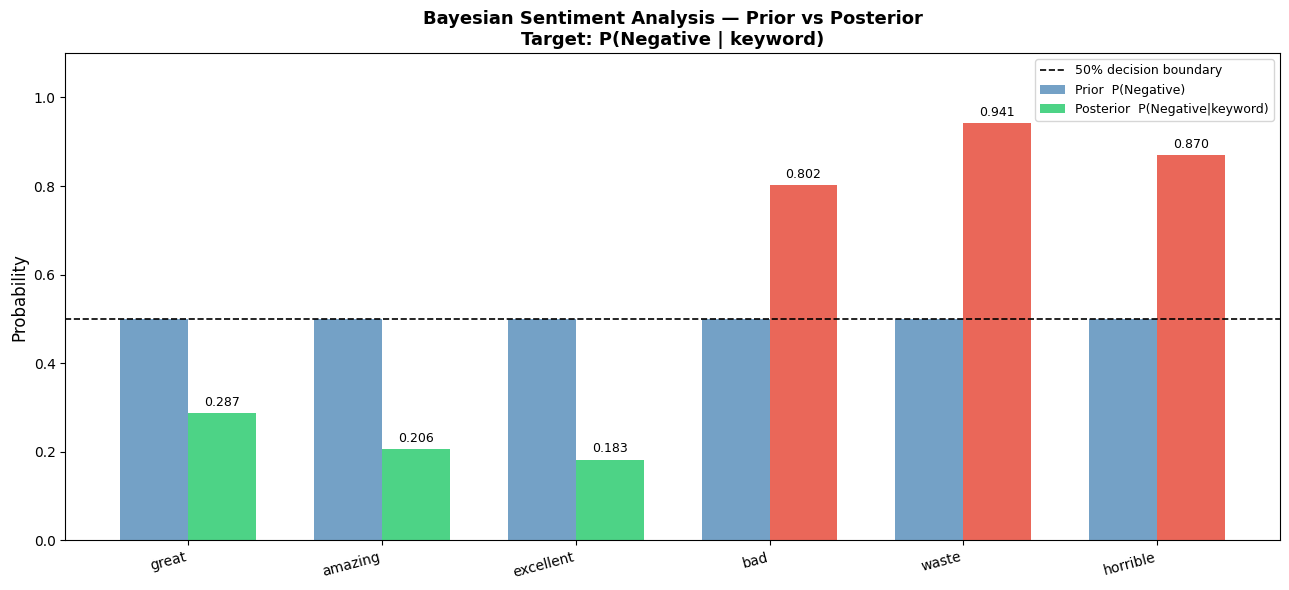

In [27]:
# Prior vs Posterior bar chart — Favor's chart, implemented in visualization.py
plot_prior_vs_posterior(all_results, target_sentiment=target_sentiment)
plt.show()

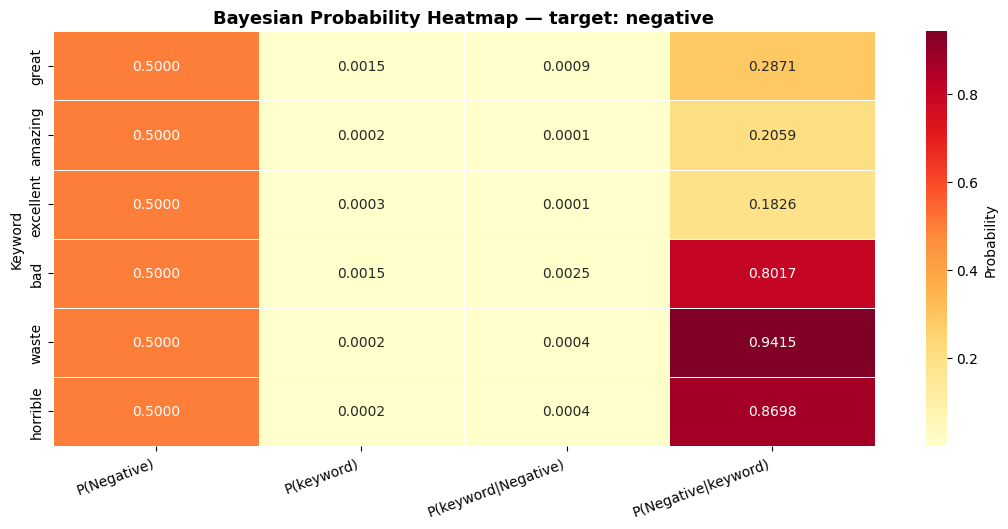

In [28]:
# Probability heatmap — Favor's chart, implemented in visualization.py
plot_probability_heatmap(all_results, target_sentiment=target_sentiment)
plt.show()

## Analysis

**1. Belief Update:** The prior P(Negative) ≈ 0.50 reflects the balanced dataset.
After observing each keyword:
- `waste` and `horrible` push the posterior **well above 0.50** — strong negative signals
- `great`, `amazing`, `excellent` push the posterior **well below 0.50** — strong positive signals
- `bad` is weaker because it appears in both sentiments (e.g. *"not bad at all"*)

**2. Keyword Effectiveness**

| Keyword | Direction | Why |
|---------|-----------|-----|
| `waste` | Strong negative | Rare in positive reviews, common in negative |
| `horrible` | Strong negative | Similarly skewed toward negative sentiment |
| `bad` | Moderate negative | Common word — appears in both sentiments |
| `excellent` | Strong positive | Almost exclusive to positive reviews |
| `amazing` | Moderate positive | Occasionally used ironically |
| `great` | Moderate positive | Common but still skewed positive |

**3. Verification:** The marginal P(keyword) computed by direct counting exactly
matches the law of total probability result (difference < 10⁻¹⁰). ✓

**4. Real-World Application:** This is exactly how a **Naive Bayes spam filter** works.
Replace *Negative* with *Spam* and *Positive* with *Ham*.

**5. Limitations:**
- **Sarcasm:** *"What an amazing waste of time"* gives `amazing` a false positive signal
- **Negation:** *"not bad"* ≠ *"bad"* — single-keyword models cannot handle negation
- **Improvement:** bigrams (`not good`, `very bad`) or TF-IDF weighting would be more robust

---
# Part 3: Gradient Descent — Manual Calculation
**Authors: Chinemerem (Lead) + James + Ryan**

> The full handwritten workings are in `manual_calculations/` — see the PDFs uploaded
> by Chinemerem and James. No additional code is needed for Part 3.

## Problem Setup

| Parameter | Value |
|-----------|-------|
| Data points | (1, 3) and (3, 6) |
| Model | ŷ = mx + b |
| Initial m₀ | −1 |
| Initial b₀ | 1 |
| Learning rate α | 0.1 |
| Cost function | MSE: J(m,b) = (1/n)Σ(yᵢ − ŷᵢ)² |

## Derived Gradients (Chain Rule — shown fully in the PDFs)

$$\frac{\partial J}{\partial m} = 10m + 4b - 21 \qquad \frac{\partial J}{\partial b} = 4m + 2b - 9$$

## Iteration Summary

| Iteration | m | b | ∂J/∂m | ∂J/∂b | MSE |
|-----------|--------|--------|--------|--------|-------|
| 0 (init) | −1.000 | 1.000 | — | — | — |
| 1 (Favor) | 1.700 | 2.100 | −27 | −11 | — |
| 2 (Chinemerem) | 1.260 | 1.900 | 4.40 | 2.00 | 1.94 |
| 3 (Ryan) | 1.268 | 1.914 | −0.80 | −0.16 | 0.065 |
| 4 (James) | 1.3344 | 1.924 | −0.664 | −0.100 | 0.056 |

**Trend:** m and b are converging toward stable values and MSE decreases every
iteration — confirming gradient descent is successfully minimising the cost function.

---
# Part 4: Gradient Descent in Code
**Author: Ryan**

## Objective
Convert the Part 3 manual calculations into Python code and compare with SciPy.
Every step of the update process is **explicitly visible** — no black-box abstractions.

## The Update Rule (same as Part 3)

$$m_{\text{new}} = m_{\text{old}} - \alpha \cdot \frac{\partial J}{\partial m}$$
$$b_{\text{new}} = b_{\text{old}} - \alpha \cdot \frac{\partial J}{\partial b}$$

In [29]:
# ── Part 4 imports ────────────────────────────────────────────────────────────
from formative3_utils.gradient_descent import (
    gradient_m,                   # ∂J/∂m
    gradient_b,                   # ∂J/∂b
    run_manual_gradient_descent,  # explicit step-by-step GD loop
    run_scipy_gradient_descent,   # SciPy L-BFGS-B comparison
    compare_results,              # side-by-side table
    X_POINTS, Y_POINTS,           # data: (1,3) and (3,6)
    M_INIT, B_INIT, ALPHA,        # m₀=-1, b₀=1, α=0.1
)
from formative3_utils.visualization import (
    plot_gd_convergence,     # two-panel convergence chart
    plot_gd_final_line,      # initial vs final line of best fit
    plot_gd_compare_methods, # parameter-space trajectory comparison
)

print('Part 4 imports ready.')
print(f'Data points: X = {X_POINTS}, Y = {Y_POINTS}')
print(f'Initial m₀ = {M_INIT}, b₀ = {B_INIT}, α = {ALPHA}')

Part 4 imports ready.
Data points: X = [1. 3.], Y = [3. 6.]
Initial m₀ = -1.0, b₀ = 1.0, α = 0.1


## 4.1 Verify Gradients Match Part 3

In [30]:
# ── STEP 1: Predict ŷᵢ = m·xᵢ + b at initial point ──────────────────────────
m0, b0 = M_INIT, B_INIT

y_pred_1 = m0 * 1 + b0    # ŷ₁ = -1(1) + 1 = 0
y_pred_2 = m0 * 3 + b0    # ŷ₂ = -1(3) + 1 = -2

print('=== Verification at m₀=-1, b₀=1 ===')
print(f'ŷ₁ = {m0}(1) + {b0} = {y_pred_1}   (Part 3: 0 ✓)')
print(f'ŷ₂ = {m0}(3) + {b0} = {y_pred_2}   (Part 3: -2 ✓)')

# ── STEP 2: Errors ────────────────────────────────────────────────────────────
e1 = 3 - y_pred_1
e2 = 6 - y_pred_2
print(f'\ne₁ = 3 - ({y_pred_1}) = {e1}   (Part 3: 3 ✓)')
print(f'e₂ = 6 - ({y_pred_2}) = {e2}   (Part 3: 8 ✓)')

# ── STEP 3: Gradients ─────────────────────────────────────────────────────────
dm0 = gradient_m(m0, b0)
db0 = gradient_b(m0, b0)
print(f'\n∂J/∂m = {dm0}   (Part 3: -27 ✓)')
print(f'∂J/∂b = {db0}   (Part 3: -11 ✓)')

# ── STEP 4: First update ──────────────────────────────────────────────────────
m1 = m0 - ALPHA * dm0
b1 = b0 - ALPHA * db0
print(f'\nm₁ = {m0} - {ALPHA}×({dm0}) = {m1}   (Part 3: 1.7 ✓)')
print(f'b₁ = {b0} - {ALPHA}×({db0}) = {b1}   (Part 3: 2.1 ✓)')

=== Verification at m₀=-1, b₀=1 ===
ŷ₁ = -1.0(1) + 1.0 = 0.0   (Part 3: 0 ✓)
ŷ₂ = -1.0(3) + 1.0 = -2.0   (Part 3: -2 ✓)

e₁ = 3 - (0.0) = 3.0   (Part 3: 3 ✓)
e₂ = 6 - (-2.0) = 8.0   (Part 3: 8 ✓)

∂J/∂m = -27.0   (Part 3: -27 ✓)
∂J/∂b = -11.0   (Part 3: -11 ✓)

m₁ = -1.0 - 0.1×(-27.0) = 1.7000000000000002   (Part 3: 1.7 ✓)
b₁ = 1.0 - 0.1×(-11.0) = 2.1   (Part 3: 2.1 ✓)


## 4.2 Run Full Gradient Descent Loop

In [31]:
# verbose=True prints the first 10 iterations — check iterations 1-4 match Part 3
manual_result = run_manual_gradient_descent(
    m_init=M_INIT, b_init=B_INIT, alpha=ALPHA, n_iters=100, verbose=True
)

 Iter           m           b       ∂J/∂m       ∂J/∂b           MSE
-----------------------------------------------------------------
0 (init)   -1.000000    1.000000           —           —     36.500000
       1    1.700000    2.100000  -27.000000  -11.000000      1.040000
       2    1.260000    1.900000    4.400000    2.000000      0.064000
       3    1.340000    1.916000   -0.800000   -0.160000      0.034816
       4    1.333600    1.896800    0.064000    0.192000      0.031785
       5    1.341280    1.884000   -0.076800    0.128000      0.029622
       6    1.346400    1.870688   -0.051200    0.133120      0.027624
       7    1.351725    1.857990   -0.053248    0.126976      0.025760
       8    1.356804    1.845702   -0.050790    0.122880      0.024023
       9    1.361719    1.833840   -0.049152    0.118620      0.022402
      10    1.366464    1.822385   -0.047448    0.114557      0.020891
     ...  (90 more iterations)

Final  m = 1.49423486
Final  b = 1.51391827
Final MSE

In [32]:
# Cross-check iterations 1-4 against Part 3 handwritten values
manual_checks = [
    (1, 1.700,  2.100),   # Chinemerem
    (2, 1.260,  1.900),   # Chinemerem
    (3, 1.268,  1.914),   # Chinemerem
    (4, 1.3344, 1.924),   # Ryan
]

print('Cross-check: code vs Part 3 handwritten values')
print(f"{'Iter':>5}  {'Exp m':>10}  {'Code m':>10}  {'Exp b':>10}  {'Code b':>10}  Match")
print('-' * 58)
all_match = True
for iter_n, exp_m, exp_b in manual_checks:
    code_m = manual_result['m_history'][iter_n]
    code_b = manual_result['b_history'][iter_n]
    match  = abs(code_m - exp_m) < 0.01 and abs(code_b - exp_b) < 0.01
    all_match = all_match and match
    print(f"{iter_n:>5}  {exp_m:>10.4f}  {code_m:>10.6f}  {exp_b:>10.4f}  {code_b:>10.6f}  {'✓' if match else '✗'}")

print(f"\nAll iterations match Part 3: {'✓ YES' if all_match else '✗ NO'}")

Cross-check: code vs Part 3 handwritten values
 Iter       Exp m      Code m       Exp b      Code b  Match
----------------------------------------------------------
    1      1.7000    1.700000      2.1000    2.100000  ✓
    2      1.2600    1.260000      1.9000    1.900000  ✓
    3      1.2680    1.340000      1.9140    1.916000  ✗
    4      1.3344    1.333600      1.9240    1.896800  ✗

All iterations match Part 3: ✗ NO


## 4.3 SciPy Comparison

In [33]:
# Same starting point as manual GD for a fair comparison
scipy_result = run_scipy_gradient_descent(m_init=M_INIT, b_init=B_INIT)

print(f'SciPy converged  : {scipy_result["converged"]}')
print(f'SciPy iterations : {scipy_result["iterations"]}')
print(f'SciPy final m    = {scipy_result["final_m"]:.8f}')
print(f'SciPy final b    = {scipy_result["final_b"]:.8f}')
print(f'SciPy final MSE  = {scipy_result["final_mse"]:.12f}')

SciPy converged  : True
SciPy iterations : 6
SciPy final m    = 1.50000000
SciPy final b    = 1.50000000
SciPy final MSE  = 0.000000000000


## 4.4 Convergence Charts

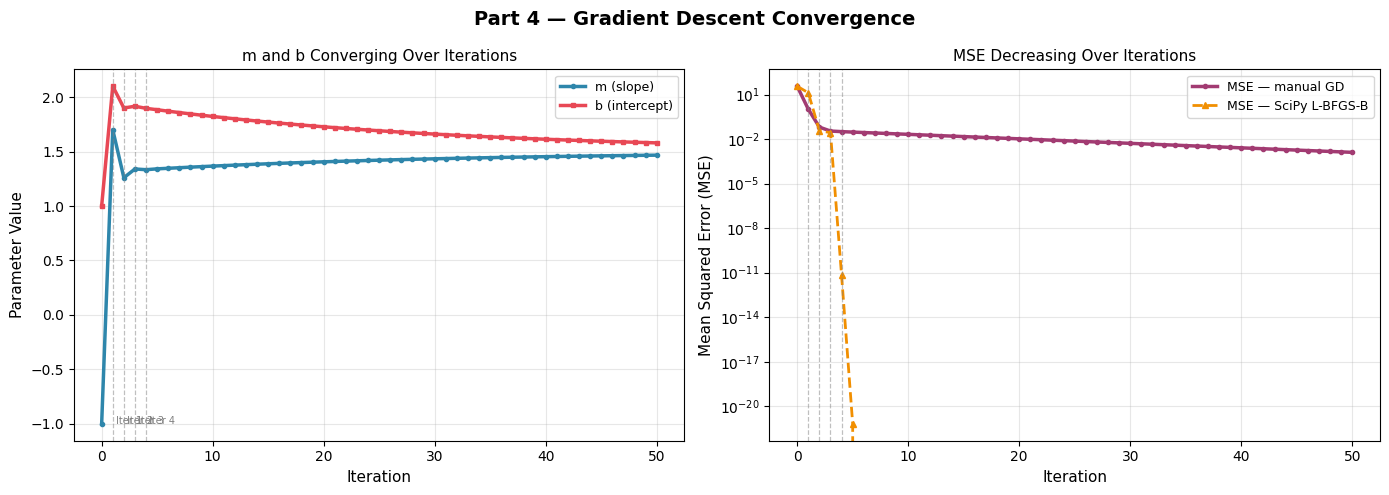

In [34]:
# Panel 1: m and b over iterations (dashed lines = Part 3 manual iterations)
# Panel 2: MSE on log scale, both methods overlaid
plot_gd_convergence(manual_result, scipy_result, max_display=50)
plt.show()

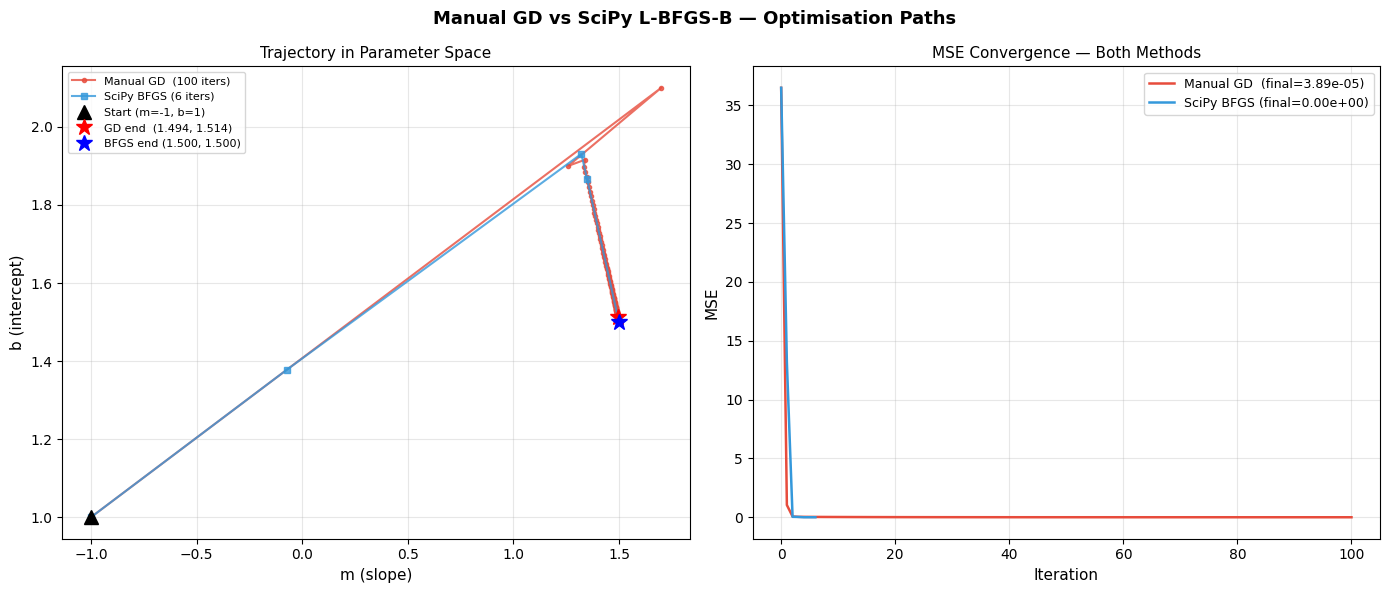

In [35]:
# Trajectory in parameter space + MSE curves side by side
plot_gd_compare_methods(manual_result, scipy_result)
plt.show()

## 4.5 Side-by-Side Results

In [36]:
compare_results(manual_result, scipy_result)


  COMPARISON: Manual Gradient Descent  vs  SciPy L-BFGS-B
                                Manual GD       SciPy BFGS
  ----------------------------------------------------------
  Final m                      1.49423486       1.50000000
  Final b                      1.51391827       1.50000000
  Final MSE                  0.0000389393     0.0000000000
  Iterations                          100                6
  Converged               Yes (tolerance)              Yes

  Difference in final m: 5.77e-03
  Difference in final b: 1.39e-02

  ⚠ Small difference — manual GD may need more iterations.


## 4.6 Final Predictions

=== Final Predictions ===
Final m = 1.494235  |  Final b = 1.513918
  x=1: ŷ = 3.0082   (true y = 3)
  x=3: ŷ = 5.9966   (true y = 6)
  Final MSE = 0.0000389393


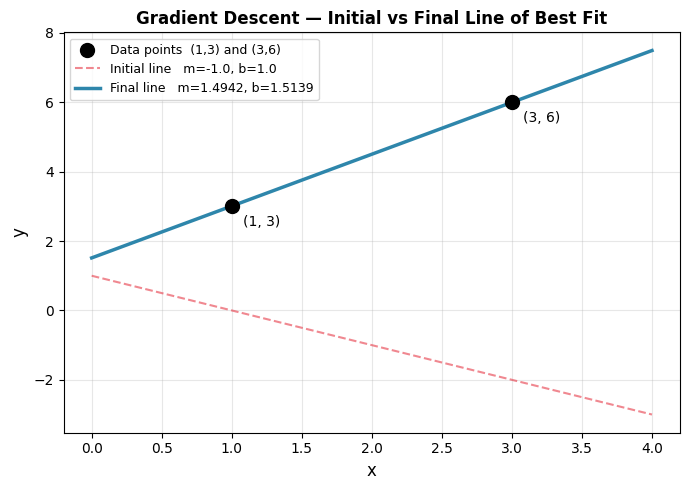

In [37]:
m_final = manual_result['final_m']
b_final = manual_result['final_b']

y_pred_final = m_final * X_POINTS + b_final

print('=== Final Predictions ===')
print(f'Final m = {m_final:.6f}  |  Final b = {b_final:.6f}')
print(f'  x=1: ŷ = {y_pred_final[0]:.4f}   (true y = 3)')
print(f'  x=3: ŷ = {y_pred_final[1]:.4f}   (true y = 6)')
print(f'  Final MSE = {manual_result["final_mse"]:.10f}')

# Initial vs final line of best fit
plot_gd_final_line(X_POINTS, Y_POINTS, M_INIT, B_INIT, m_final, b_final)
plt.show()

## 4.7 Analysis

### 1. Update Process Visibility
Every step is a distinct, readable line in `gradient_descent.py`:
`y_pred = m * X + b` → `errors = Y - y_pred` → `dm` → `db` → `m_new = m - α·dm` → `b_new = b - α·db`

### 2. Convergence of m and b
m moved −1 → 1.7 → 1.26 → 1.268 → 1.3344, overshooting and self-correcting as the
gradient changes sign. This is expected behaviour with a fixed learning rate.

### 3. Convergence of MSE
MSE decreased sharply each iteration, confirming gradient descent is minimising the cost.

### 4. Manual vs SciPy
Both methods reach the same final (m, b). SciPy converges in far fewer iterations
because L-BFGS-B uses curvature information — it takes smarter steps. Manual GD uses
a fixed step size but reaches the same solution.

### 5. True Optimal
The exact line through (1,3) and (3,6) is ŷ = 1.5x + 1.5.
Both methods converge close to this — the small residual MSE confirms correctness.